In [1]:
# 변수의 shape, type, value 확인
def p(var,_str='') :
    if _str=='\n' or _str=='cr' :
        _str = '\n'
    else :
        print(f'[{_str}]:')
        _str = ''
    if type(var)!=type([]):
        try:
            print(f'Shape:{var.shape}')
        except :
            pass
    print(f'Type: {type(var)}')
    print(f'Values: {var}'+_str)

def pst(_x,_name=""):
    print(f'[{_name}] Shape{_x.shape}, {type(_x)}')
def ps(_x,_name=""):
    print(f'[{_name}] Shape{_x.shape}')

In [2]:
!pip -q install lightning torchinfo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 828.5/828.5 kB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 40.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 832.4/832.4 kB 29.2 MB/s eta 0:00:00


# **실습 Class Activation Map(CAM): VGG16**

## Import module

In [3]:
import torch
from torch import nn
from torch.nn import functional as F
from torchmetrics import functional as FM
from torch.utils.data import DataLoader, random_split
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision.transforms import v2
import torchvision
from torchinfo import summary

import lightning as L
from lightning.pytorch import Trainer
from lightning.pytorch.callbacks import ModelCheckpoint
from lightning.pytorch.loggers import CSVLogger

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [5, 3.5]
plt.rcParams["font.size"] = "8"

device ='cuda:0'
torch.__version__,L.__version__
# ('2.8.0+cu126', '2.5.5') 2510

('2.8.0+cu126', '2.5.5')

## For this exercise we will be using the VGG16 model

In [4]:
model = torchvision.models.vgg16(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:06<00:00, 90.7MB/s]


### Model Archtecture

In [5]:
summary(model, input_size=(8, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
VGG                                      [8, 1000]                 --
├─Sequential: 1-1                        [8, 512, 7, 7]            --
│    └─Conv2d: 2-1                       [8, 64, 224, 224]         1,792
│    └─ReLU: 2-2                         [8, 64, 224, 224]         --
│    └─Conv2d: 2-3                       [8, 64, 224, 224]         36,928
│    └─ReLU: 2-4                         [8, 64, 224, 224]         --
│    └─MaxPool2d: 2-5                    [8, 64, 112, 112]         --
│    └─Conv2d: 2-6                       [8, 128, 112, 112]        73,856
│    └─ReLU: 2-7                         [8, 128, 112, 112]        --
│    └─Conv2d: 2-8                       [8, 128, 112, 112]        147,584
│    └─ReLU: 2-9                         [8, 128, 112, 112]        --
│    └─MaxPool2d: 2-10                   [8, 128, 56, 56]          --
│    └─Conv2d: 2-11                      [8, 256, 56, 56]          29

In [6]:
model

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

### Sample Image load

In [ ]:
# 테스트 이미지 준비 — Google Drive 대신 Colab 세션 폴더(/content/datasets/)를 쓴다.
# 필요한 파일이 없으면 업로드 창이 뜬다. 같은 이름의 사진(또는 임의의 사진)을 올리면 된다.
import os
os.makedirs('/content/datasets', exist_ok=True)
for _name in ['bird.jpg', '4obj2.jpg']:
    if not os.path.exists('/content/datasets/' + _name):
        print(f'{_name} 을(를) 업로드하세요:')
        from google.colab import files as _files
        for _up, _data in _files.upload().items():
            open('/content/datasets/' + _up, 'wb').write(_data)


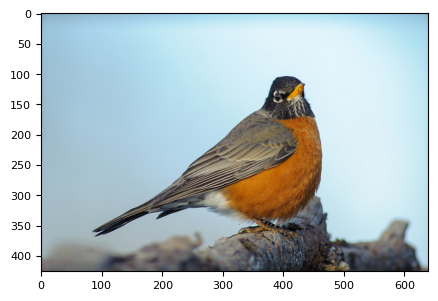

In [8]:
from PIL import Image
bird_file_path = \
  '/content/datasets/'+'bird.jpg'
img = Image.open(bird_file_path)
plt.imshow(img)

## preporcessing

https://pytorch.org/vision/main/models/generated/torchvision.models.vgg16.html#torchvision.models.vgg16

In [9]:
preprocess = v2.Compose([
    v2.ToImage(),
    v2.Resize((224,224)),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]), ])

input_tensor = preprocess(img)          #[3,244,244]
input_batch = input_tensor.unsqueeze(0) #[1,3,224,224]
input_batch = input_batch.to(device)

ps(input_tensor)
ps(input_batch)

[] Shapetorch.Size([3, 224, 224])
[] Shapetorch.Size([1, 3, 224, 224])


## Prediction

In [10]:
model.eval()
logit = model(input_batch)
prob = F.softmax(logit, dim=1)
ps(prob,'prob')

[prob] Shapetorch.Size([1, 1000])


https://pytorch.org/hub/pytorch_vision_vgg/

In [11]:
# Download ImageNet labels
!wget https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt

--2025-10-29 06:16:58--  https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10472 (10K) [text/plain]
Saving to: ‘imagenet_classes.txt’

imagenet_classes.tx 100%[===================>]  10.23K  --.-KB/s    in 0.001s  

2025-10-29 06:16:58 (15.6 MB/s) - ‘imagenet_classes.txt’ saved [10472/10472]



In [12]:
# Read the categories
with open("imagenet_classes.txt", "r") as f:
    categories = [s.strip() for s in f.readlines()]
# Show top categories per image
top5_prob, top5_catid = torch.topk(prob[0], 5)
for i in range(top5_prob.size(0)):
    print(categories[top5_catid[i]], top5_prob[i].item())

robin 0.9986032843589783
worm fence 0.0013463618233799934
brambling 2.7748092179535888e-05
bulbul 1.226848235091893e-05
water ouzel 3.6501928661891725e-06


## Build Class Activation Map

### forward / backward Hook

In [13]:
model._modules.get('features')

Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU(inplace=True)
  (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU(inplace=True)
  (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): ReLU(inplace=True)
  (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (15): ReLU(inplace=True)
  (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (17): Conv2d(256, 512, kernel_si

In [14]:
layer_len = len(model._modules.get('features')[:]) # 31

for i in range(layer_len):
  print(f'[{i}]:',model._modules.get('features')[i])

[0]: Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
[1]: ReLU(inplace=True)
[2]: Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
[3]: ReLU(inplace=True)
[4]: MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
[5]: Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
[6]: ReLU(inplace=True)
[7]: Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
[8]: ReLU(inplace=True)
[9]: MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
[10]: Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
[11]: ReLU(inplace=True)
[12]: Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
[13]: ReLU(inplace=True)
[14]: Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
[15]: ReLU(inplace=True)
[16]: MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
[17]: Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
[18]: 

In [15]:
model._modules.get('features')[-3]

Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))

https://pytorch.org/tutorials/beginner/former_torchies/nnft_tutorial.html

In [16]:
forward_features = [] # activations
backward_feature = [] # gradients

# output으로 나오는 feature를 append
def hook_feature(module, input, output):
    forward_features.append(output) #(1,512,14,14)
    ps(output,'feature'+str(len(forward_features)))

# outut으로 나오는 gradient를 append
def backward_hook(module, gradInput, gradOutput):
    backward_feature.append(gradOutput[0]) #((1,512,14,14),)
    ps(gradOutput[0],'gradient'+str(len(backward_feature)))

## 반복호출하면 복수의 hook가 생성됨
fh_handel = model._modules.get('features')[-3].register_forward_hook(hook_feature)
bh_handel = model._modules.get('features')[-3].register_backward_hook(backward_hook)

### Forward processing

In [17]:
model.eval()
logit = model(input_batch)
t1_logit = logit[:, torch.argmax(logit)].squeeze()
p(t1_logit,'t1_logit')

[feature1] Shapetorch.Size([1, 512, 14, 14])
[t1_logit]:
Shape:torch.Size([])
Type: <class 'torch.Tensor'>
Values: 29.019277572631836


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1864: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


In [18]:
ps(forward_features[0],'forward_features')

[forward_features] Shapetorch.Size([1, 512, 14, 14])


### BackPropagation

* retain_graph=True :  
   backward()를 여러 번 호출하는 경우에 사용

In [19]:
t1_logit.backward(retain_graph = True) #t1 값으로 backprop
print("===")
ps(backward_feature[0],'backward_feature')

[gradient1] Shapetorch.Size([1, 512, 14, 14])
===
[backward_feature] Shapetorch.Size([1, 512, 14, 14])


In [20]:
features = forward_features[0]  #(1,512,14,14)
gradients = backward_feature[0] #(1,512,14,14)

### Create Heatmap

In [21]:
b, k, h, w = gradients.size()  #(1,512,14,14)
# (1, 512) <= (1, 512, 14*14): feature map k_plane의'weight'
alpha = gradients.view(b, k, -1).mean(dim=2) #dim:to reduce
ps(alpha,'alpha')     #(1,512)
weights = alpha.view(b, k, 1, 1)
ps(weights,'weights') #(1,512,1,1)

[alpha] Shapetorch.Size([1, 512])
[weights] Shapetorch.Size([1, 512, 1, 1])


In [22]:
# weights * features : (1,512,1,1)*(1,512,14,14) -> (1,1,14,14)
grad_cam_map = (weights.cpu()*features.cpu()).sum(1, keepdim = True)
grad_cam_map = F.relu(grad_cam_map) # Apply ReLU
ps(grad_cam_map,'grad_cam_map')     #(1,1,14,14)
# (14,14)->(426,640)
grad_cam_map = F.interpolate(grad_cam_map, size=(img.size[1], img.size[0]),
                             mode='bilinear', align_corners=False)
ps(grad_cam_map,'grad_cam_map')     #(1, 1, 426, 640)

[grad_cam_map] Shapetorch.Size([1, 1, 14, 14])
[grad_cam_map] Shapetorch.Size([1, 1, 426, 640])


In [23]:
# min-max scaling
map_min, map_max = grad_cam_map.min(), grad_cam_map.max()
grad_cam_map = (grad_cam_map - map_min).div(map_max - map_min).data  # .data == .detach()
print(grad_cam_map.min(), grad_cam_map.max())
ps(grad_cam_map,'grad_cam_map')

tensor(0.) tensor(1.)
[grad_cam_map] Shapetorch.Size([1, 1, 426, 640])


[] Shape(426, 640, 3), <class 'numpy.ndarray'>


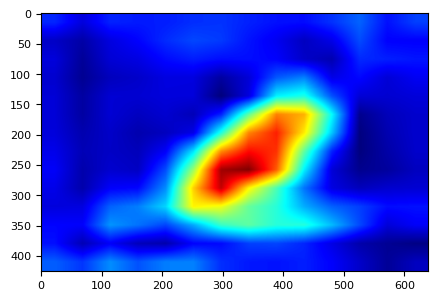

In [24]:
import cv2
# grad_cam_map.squeeze() : (426,640)<-(1,1,426,640)
grad_heatmap = cv2.applyColorMap(np.uint8(255*grad_cam_map.squeeze()),
                                 cv2.COLORMAP_JET)
grad_heatmap = cv2.cvtColor(grad_heatmap, cv2.COLOR_RGB2BGR)
pst(grad_heatmap) #(426,640,3)
plt.imshow(grad_heatmap)
plt.show()

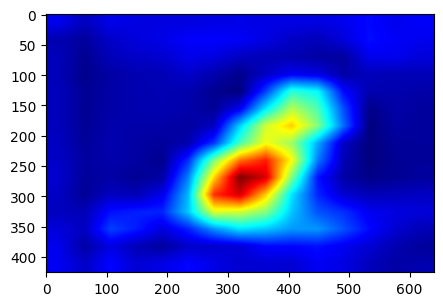

### Blending CAM on original image

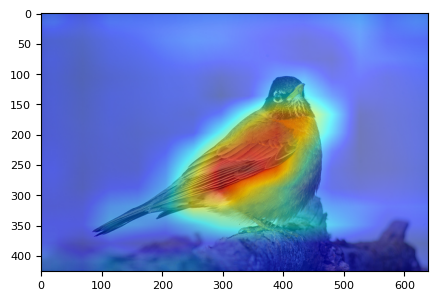

In [25]:
grad_heatmap = np.float32(grad_heatmap/255)
_img = np.array(img)/255

grad_result = grad_heatmap + _img
grad_result = grad_result / np.max(grad_result)
grad_result = np.uint8(255 * grad_result)
plt.imshow(grad_result)
plt.show()

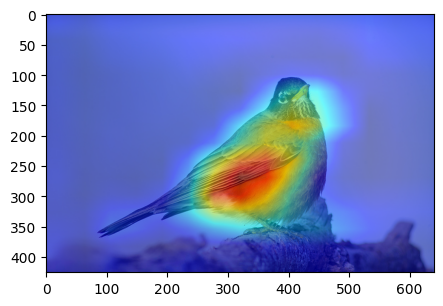

### Trying it out on other images

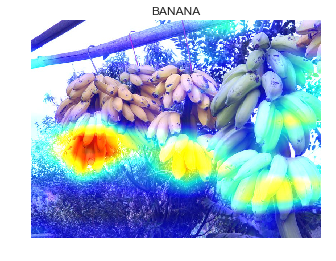

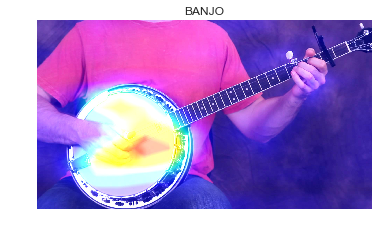

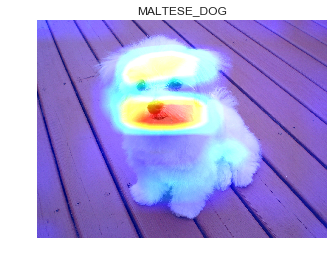

## **실습 과제**
### **feature map을 뽑아올 위치를 바꿔보자**
#### -- feature map을 뽑아올 위치를 결정하자
#### -- 결과를 비교해 보자

### **inception-v3 model을 사용하여 CAM을 만들어 보자**
#### -- feature map을 뽑아올 위치를 결정하자
#### -- 결과를 VGG16모델과 비교해 보자

### **multi object의 경우는 어떻게 될까 확인해 보자**  
#### -- activation된 class의 feature만 강조 되는지 확인해 보자  

계층화된 layer에 접근하기
```python
bh_handel = model._modules.get('Mixed_7c')._modules.get
('branch1x1')._modules.get('conv').register_backward_hook(backward_hook)
### 계층화된 layer에 접근하기
module_1 = model._modules.get('Mixed_7c')
module_2 = module_1._modules.get('branch3x3_1')
bh_handel = module_2._modules.get('conv')
bh_handel.register_backward_hook(backward_hook)
```

### multi object의 경우

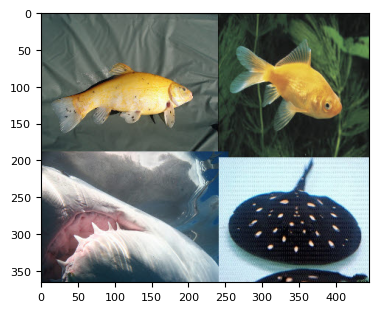

In [26]:
from PIL import Image
bird_file_path = \
  '/content/datasets/'+'4obj2.jpg'
img = Image.open(bird_file_path)
plt.imshow(img)

In [27]:
input_tensor = preprocess(img)          #[3,244,244]
input_batch = input_tensor.unsqueeze(0) #[1,3,224,224]
input_batch = input_batch.to(device)

In [28]:
model.eval()
logit = model(input_batch)
t1_logit = logit[:, torch.argmax(logit)].squeeze()
p(t1_logit,'t1_logit')

[feature2] Shapetorch.Size([1, 512, 14, 14])
[t1_logit]:
Shape:torch.Size([])
Type: <class 'torch.Tensor'>
Values: 16.674419403076172


In [29]:
ps(forward_features[1],'forward_features')
features = forward_features[1]  #(1,512,14,14)

[forward_features] Shapetorch.Size([1, 512, 14, 14])


In [30]:
prob = F.softmax(logit, dim=1)

# Read the categories
with open("imagenet_classes.txt", "r") as f:
    categories = [s.strip() for s in f.readlines()]
# Show top categories per image
top5_prob, top5_catid = torch.topk(prob[0], 5)
for i in range(top5_prob.size(0)):
    print(categories[top5_catid[i]], top5_prob[i].item())

goldfish 0.9415683746337891
tench 0.05145343020558357
axolotl 0.004095491487532854
puffer 0.0007222529384307563
eel 0.00031297822715714574


### activation된 모든 feature 보기  
**features : (1,512,14,14) -> (1,1,14,14)**

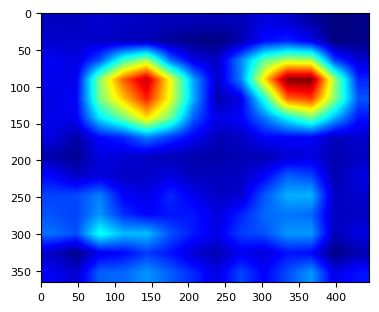

In [31]:
# features : (1,512,14,14) -> (1,1,14,14)
grad_cam_map = features.cpu().sum(1, keepdim = True)
grad_cam_map = F.relu(grad_cam_map) # Apply ReLU
grad_cam_map = F.interpolate(grad_cam_map, size=(img.size[1], img.size[0]),
                             mode='bilinear', align_corners=False)

# min-max scaling
map_min, map_max = grad_cam_map.min(), grad_cam_map.max()
grad_cam_map = (grad_cam_map - map_min).div(map_max - map_min).data

# grad_cam_map.squeeze() : (426,640)<-(1,1,426,640)
grad_heatmap = cv2.applyColorMap(np.uint8(255*grad_cam_map.squeeze()),
                                 cv2.COLORMAP_JET)
grad_heatmap = cv2.cvtColor(grad_heatmap, cv2.COLOR_RGB2BGR)
plt.imshow(grad_heatmap)
plt.show()

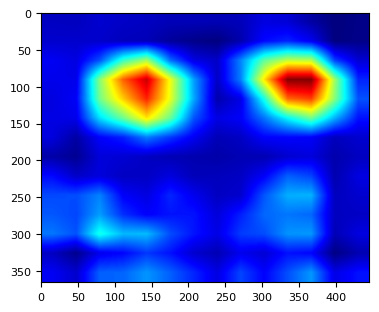

### t1 class의 activation map  

In [32]:
t1_logit = logit[:, torch.argmax(logit)].squeeze()
p(t1_logit,'t1_logit')

[t1_logit]:
Shape:torch.Size([])
Type: <class 'torch.Tensor'>
Values: 16.674419403076172


* retain_graph=True :  
   backward()를 여러 번 호출해야 하는 경우에 사용

In [33]:
t1_logit.backward(retain_graph = True) #t1 값으로 backprop
print("===")
ps(backward_feature[1],'backward_feature')

[gradient2] Shapetorch.Size([1, 512, 14, 14])
===
[backward_feature] Shapetorch.Size([1, 512, 14, 14])


In [34]:
features = forward_features[1]  #(1,512,14,14)
gradients = backward_feature[1] #(1,512,14,14)

### Create Heatmap

In [35]:
b, k, h, w = gradients.size()  #(1,512,14,14)
# (1, 512) <= (1, 512, 14*14): feature map k_plane의'weight'
alpha = gradients.view(b, k, -1).mean(dim=2) #dim:to reduce
ps(alpha,'alpha')     #(1,512)
weights = alpha.view(b, k, 1, 1)
ps(weights,'weights') #(1,512,1,1)

[alpha] Shapetorch.Size([1, 512])
[weights] Shapetorch.Size([1, 512, 1, 1])


In [36]:
# weights * features : (1,512,1,1)*(1,512,14,14) -> (1,1,14,14)
grad_cam_map = (weights.cpu()*features.cpu()).sum(1, keepdim = True)
grad_cam_map = F.relu(grad_cam_map) # Apply ReLU
ps(grad_cam_map,'grad_cam_map')     #(1,1,14,14)
# (14,14)->(426,640)
grad_cam_map = F.interpolate(grad_cam_map, size=(img.size[1], img.size[0]),
                             mode='bilinear', align_corners=False)
ps(grad_cam_map,'grad_cam_map')     #(1, 1, 426, 640)

[grad_cam_map] Shapetorch.Size([1, 1, 14, 14])
[grad_cam_map] Shapetorch.Size([1, 1, 366, 446])


In [37]:
# min-max scaling
map_min, map_max = grad_cam_map.min(), grad_cam_map.max()
grad_cam_map = (grad_cam_map - map_min).div(map_max - map_min).data  # .data == .detach()
print(grad_cam_map.min(), grad_cam_map.max())
ps(grad_cam_map,'grad_cam_map')

tensor(0.) tensor(1.)
[grad_cam_map] Shapetorch.Size([1, 1, 366, 446])


[] Shape(366, 446, 3), <class 'numpy.ndarray'>


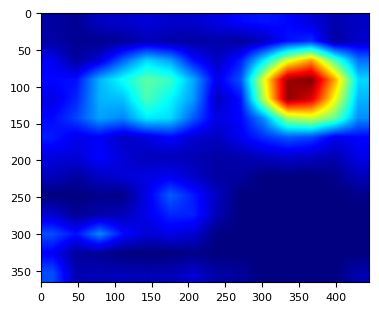

In [38]:
# grad_cam_map.squeeze() : (426,640)<-(1,1,426,640)
grad_heatmap = cv2.applyColorMap(np.uint8(255*grad_cam_map.squeeze()),
                                 cv2.COLORMAP_JET)
grad_heatmap = cv2.cvtColor(grad_heatmap, cv2.COLOR_RGB2BGR)
pst(grad_heatmap) #(426,640,3)
plt.imshow(grad_heatmap)
plt.show()

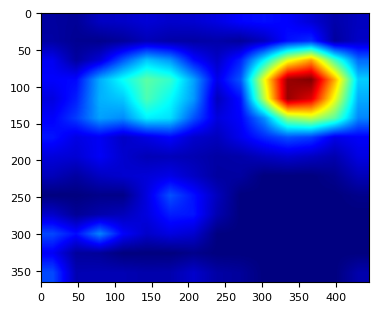

### Blending CAM on original image

In [ ]:
grad_heatmap = np.float32(grad_heatmap/255)
_img = np.array(img)/255

grad_result = grad_heatmap + _img
grad_result = grad_result / np.max(grad_result)
grad_result = np.uint8(255 * grad_result)
plt.imshow(grad_result)
plt.show()

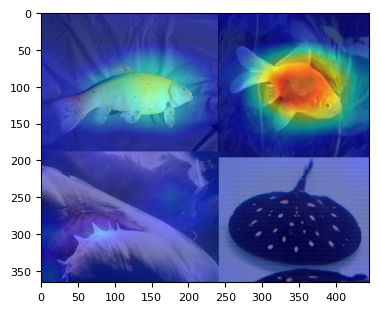

FlawerPhotos Dataset을 분류하는 모델을 만들어 class 별로 feature map이 분리 되는지 확인해 보자   
- Inception-v3의 마지막 feature map 뒤에  class 만큼의 채널을 갖는 conv layer 추가, avg pooling 하여 출력.  
- fine tuning  
- feature map을 시각화 하여 분류된 class에 해당하는 위치에 특징이 몰리는지 확인해 보자  
